In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from plotnine import *

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

# dendrograms
import scipy.cluster.hierarchy as sch
from matplotlib import pyplot as plt


%matplotlib inline

Behavioral Clustering

In [ ]:
# read in data
behav = pd.read_csv("https://raw.githubusercontent.com/cmparlettpelleriti/CPSC392ParlettPelleriti/master/Data/HW3_behavioral.csv")

behav.head()

,age,current_income,time_spent_browsing,length_of_subscription,monthly_visits,longest_read_time,gender,prop_ads_clicked,id
0,57,74.94,680.185910,344.260552,33.612656,252.092201,man,0.177864,90
1,47,67.01,554.768760,330.549067,28.924096,119.694118,woman,0.138873,1
2,49,66.71,618.436797,247.549601,28.274578,321.450862,woman,0.200859,125
3,47,79.20,560.599752,269.378967,30.471076,179.349038,woman,0.191236,164
4,50,68.39,628.441198,260.282353,32.486453,213.114138,man,0.089133,75


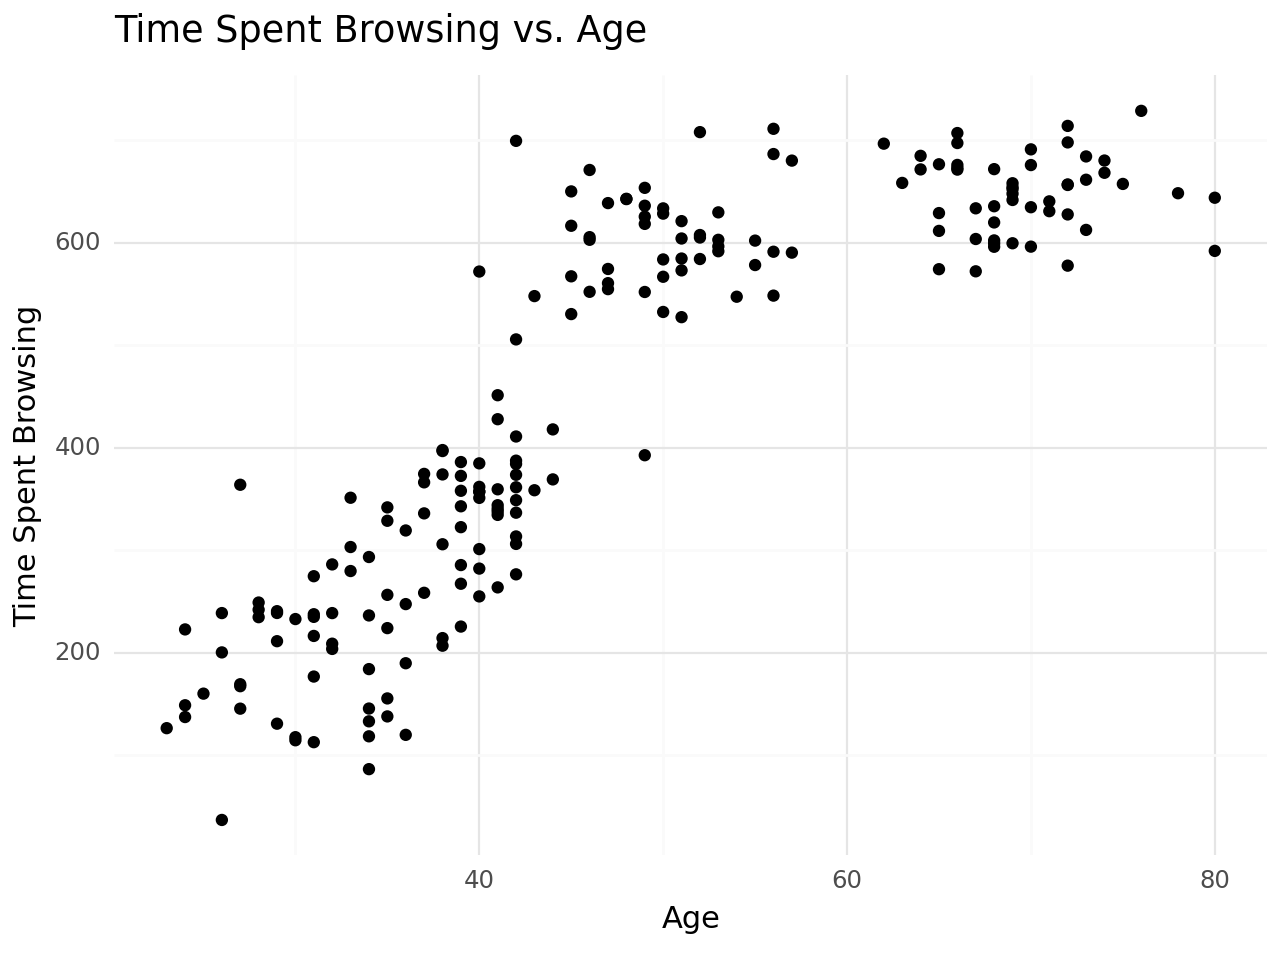

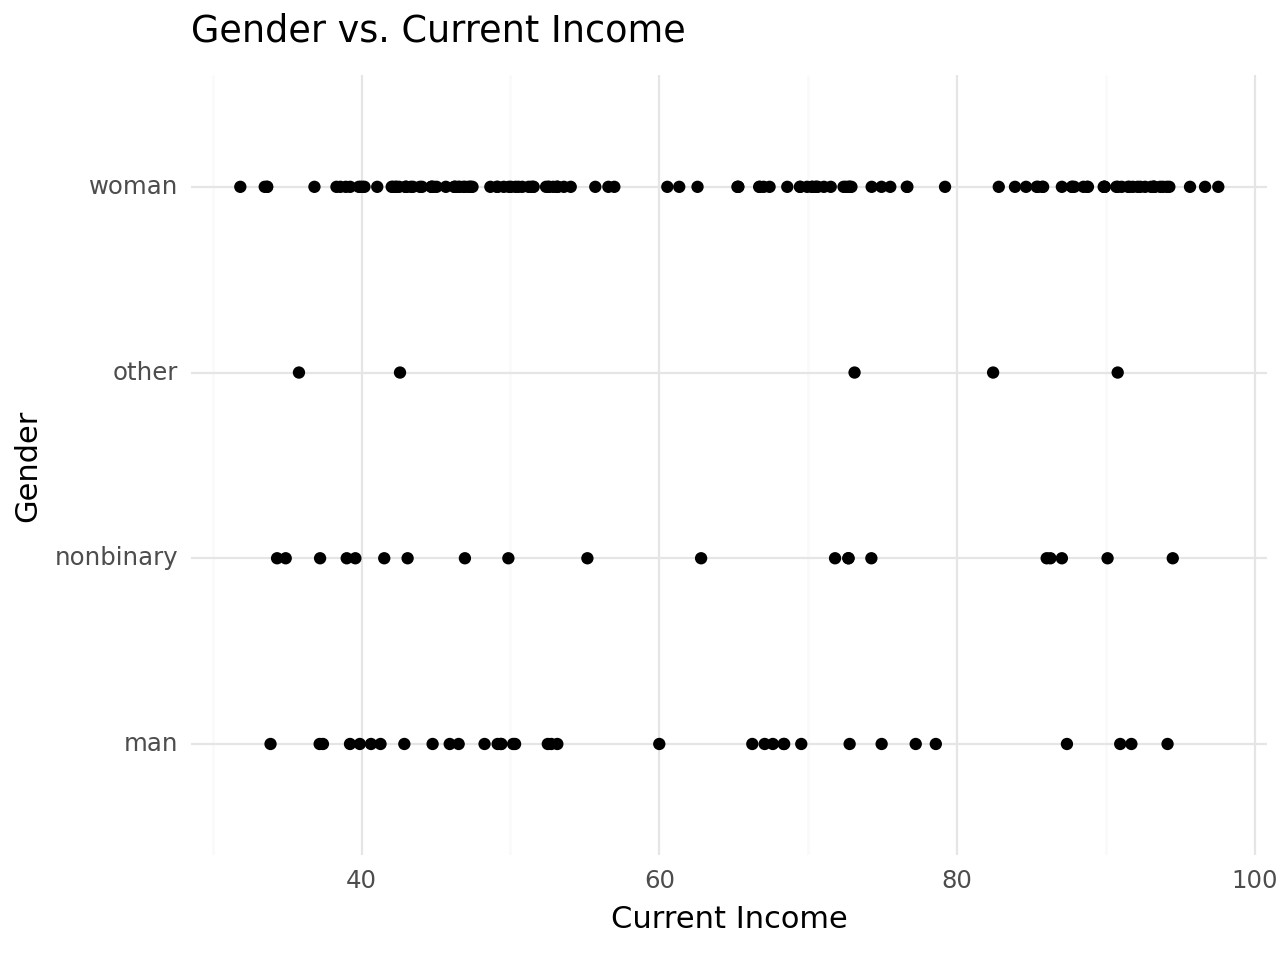

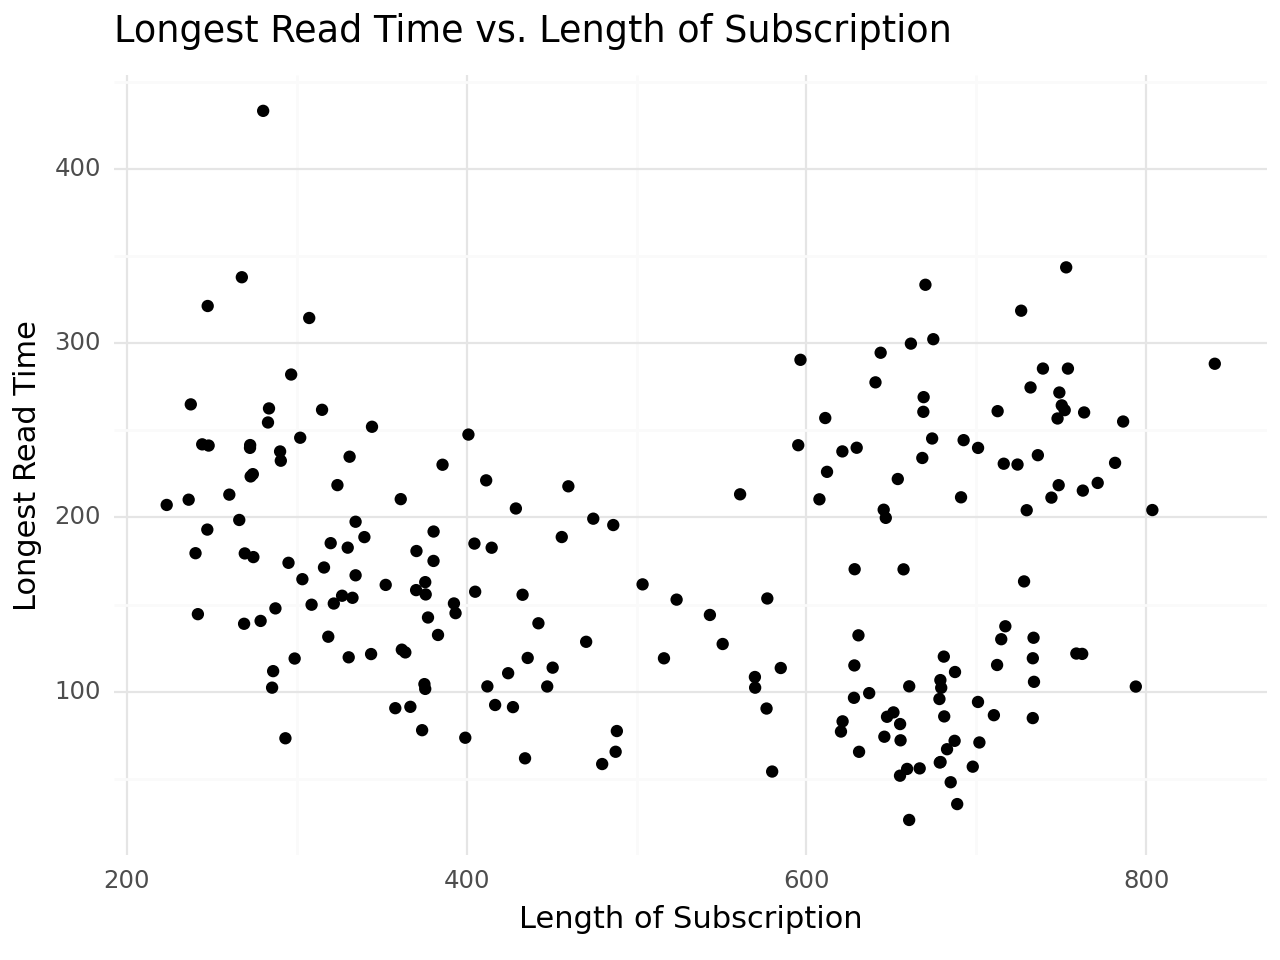

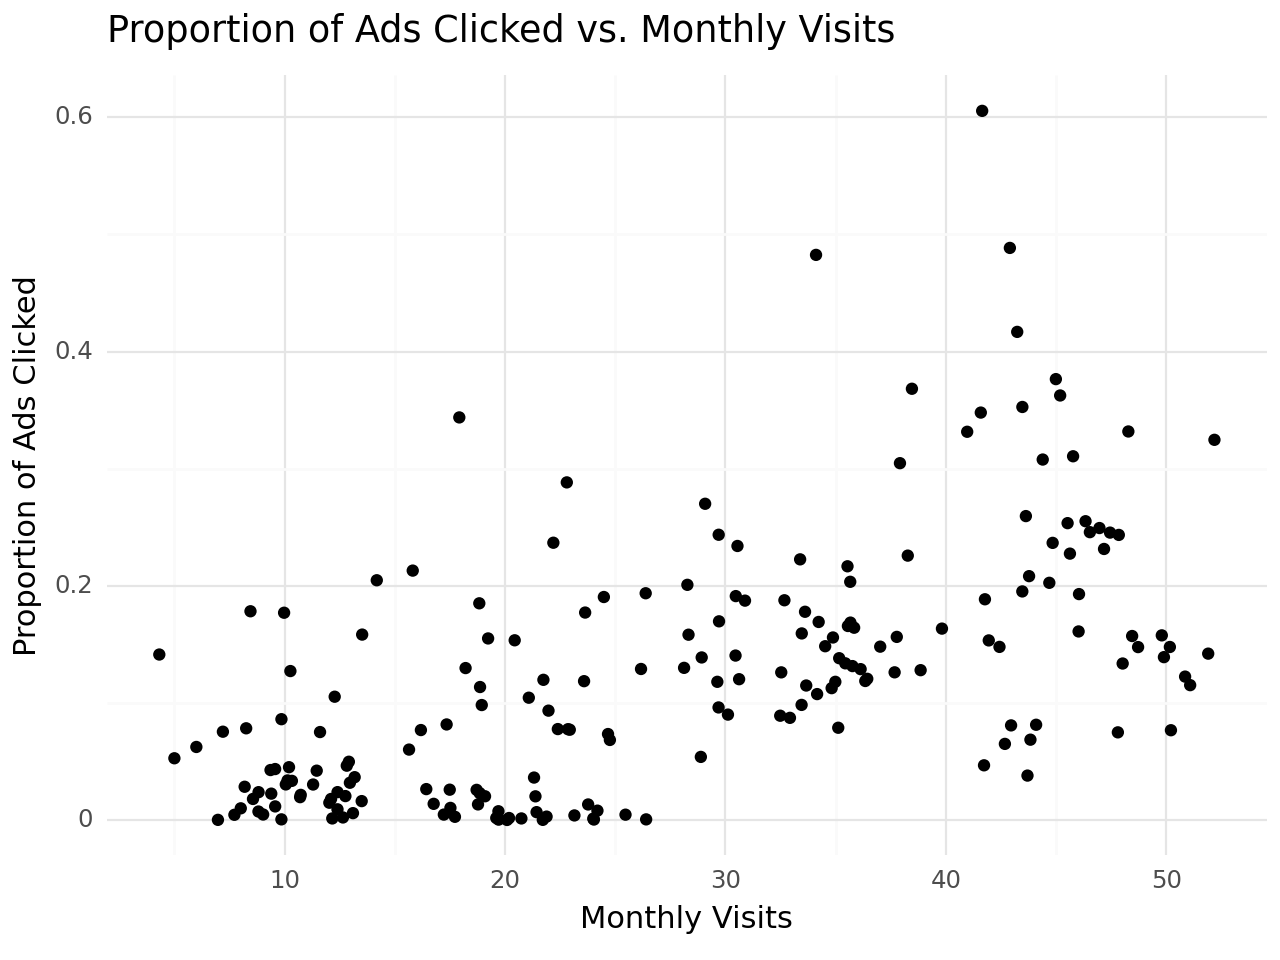

In [ ]:
# ggplot scatterplots

print(ggplot(behav, aes(x = "age", y = "time_spent_browsing")) +
  geom_point() +
  labs(x = "Age", y = "Time Spent Browsing", title = "Time Spent Browsing vs. Age") +
  theme_minimal())

print(ggplot(behav, aes(x = "current_income", y = "gender")) +
  geom_point() +
  labs(x = "Current Income", y = "Gender", title = "Gender vs. Current Income") +
  theme_minimal())

print(ggplot(behav, aes(x = "length_of_subscription", y = "longest_read_time")) +
  geom_point() +
  labs(x = "Length of Subscription", y = "Longest Read Time", title = "Longest Read Time vs. Length of Subscription") +
  theme_minimal())

print(ggplot(behav, aes(x = "monthly_visits", y = "prop_ads_clicked")) +
  geom_point() +
  labs(x = "Monthly Visits", y = "Proportion of Ads Clicked", title = "Proportion of Ads Clicked vs. Monthly Visits") +
  theme_minimal())

In [ ]:
# set up features
features = ["age", "current_income", "time_spent_browsing", "length_of_subscription", "monthly_visits", "longest_read_time", "prop_ads_clicked"]
X = behav[features]

# create empty model
z = make_column_transformer((StandardScaler(), features),
                            remainder = "passthrough")

hac = AgglomerativeClustering(affinity = "euclidean",
                             linkage = "ward",
                             distance_threshold=0,
                             n_clusters = None)

pipe = Pipeline([("z", z),
                 ("model", hac)])


# fit model and get labels
labels = pipe.fit_predict(X[features])

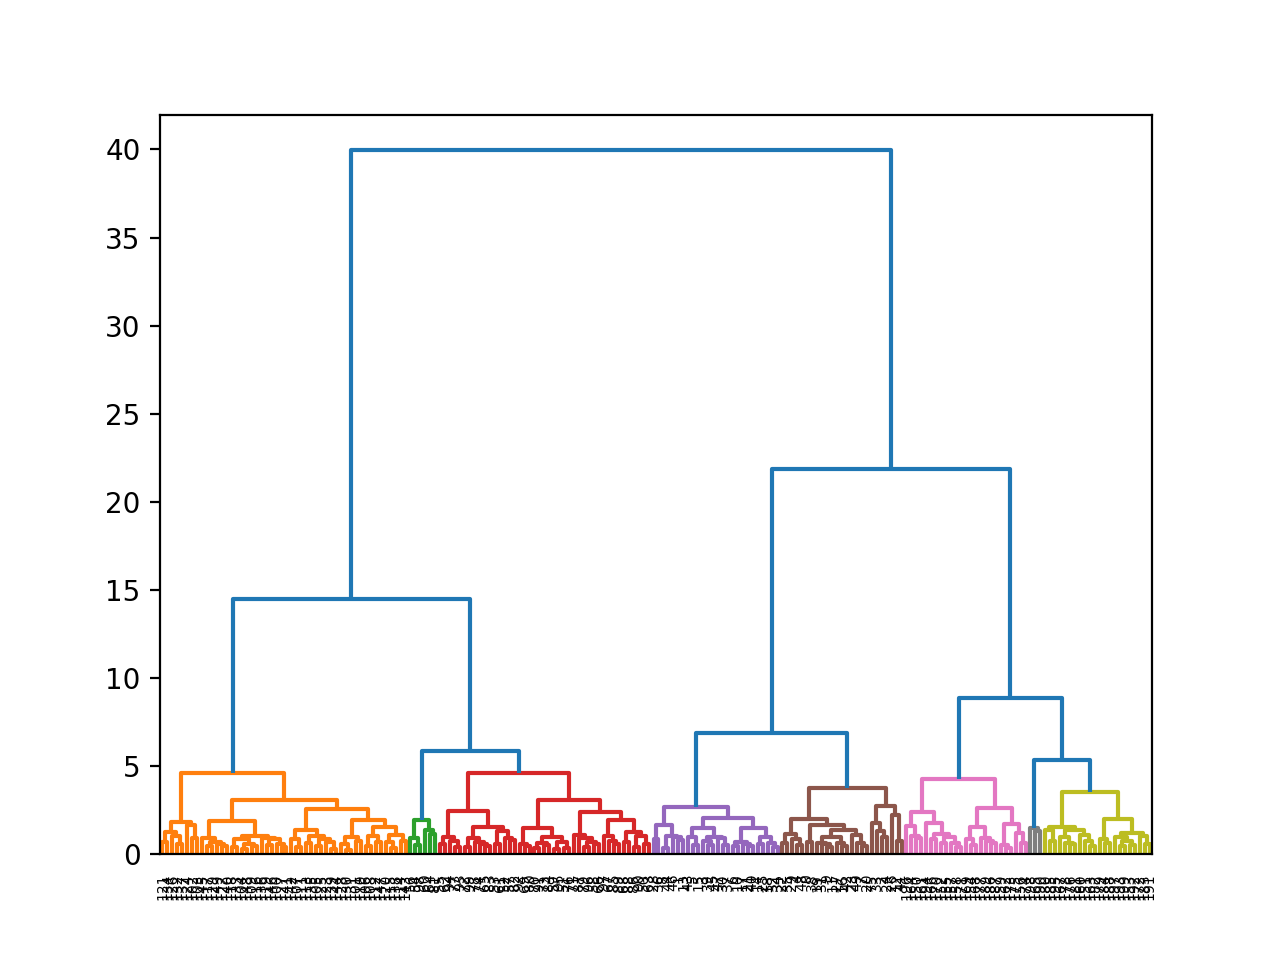

In [ ]:
# choosing number of clusters
def plot_dendrogram(pipe, **kwargs):

    if "model" not in pipe.named_steps.keys():
        raise NameError("Your clustering pipeline step must be called 'model' for this function to work.")

    # create the counts of samples under each node
    counts = np.zeros(pipe.named_steps["model"].children_.shape[0])
    n_samples = len(pipe.named_steps["model"].labels_)
    for i, merge in enumerate(pipe.named_steps["model"].children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [pipe.named_steps["model"].children_, pipe.named_steps["model"].distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    sch.dendrogram(linkage_matrix, **kwargs)


plot_dendrogram(pipe, color_threshold = 5)

In [ ]:
# refit model with # of clusters you want
hac = AgglomerativeClustering(affinity = "euclidean",
                             linkage = "ward",
                             distance_threshold=None,
                             n_clusters = 4) # number of clusters decided based of dendrogram

pipe = Pipeline([("z", z),
                 ("model", hac)])

# fit model and get labels
labels = pipe.fit_predict(X[features])

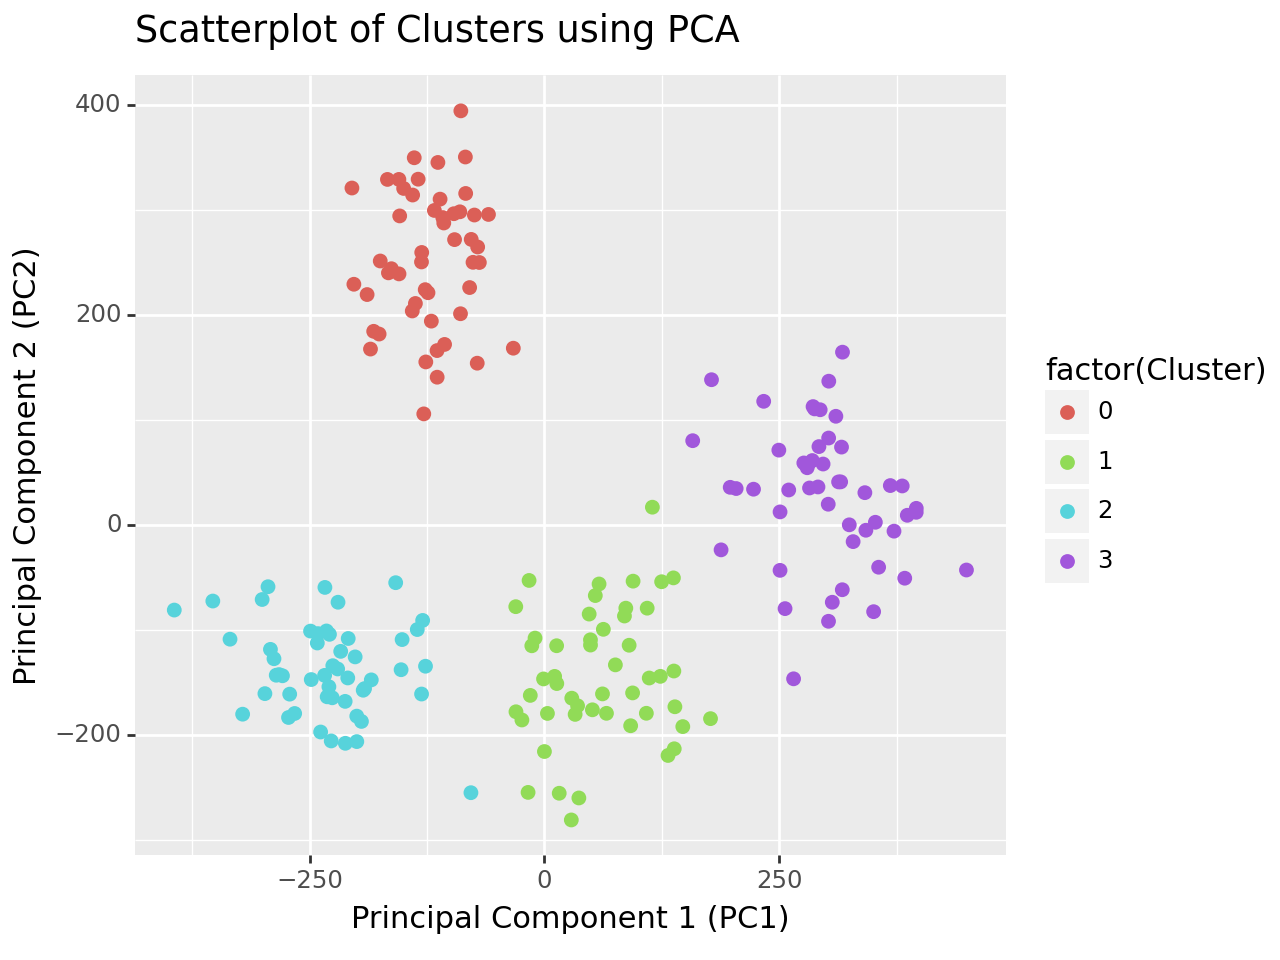

In [ ]:
# PCA
# apply PCA to original features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# add cluster labels to the PCA-transformed data
X_pca_with_labels = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca_with_labels["Cluster"] = labels

# plot scatterplot with color-coded clusters
print(ggplot(X_pca_with_labels, aes(x="PC1", y="PC2", color="factor(Cluster)")) +
               geom_point(size=2) +
               ggtitle("Scatterplot of Clusters using PCA") +
               xlab("Principal Component 1 (PC1)") +
               ylab("Principal Component 2 (PC2)"))

In [ ]:
# performance of model based on dendrogram
print(silhouette_score(X[features], labels))

0.6119422076905741


   Cluster        age  current_income  time_spent_browsing  \
0        0  69.380000       90.149800           645.677263   
1        1  39.857143       49.743061           342.060758   
2        2  49.862745       69.980196           600.797654   
3        3  30.700000       40.713400           199.091869   

   length_of_subscription  monthly_visits  longest_read_time  prop_ads_clicked  
0              698.608170       45.221277         244.238716          0.228305  
1              407.616388       21.031827         140.816451          0.065174  
2              298.499386       33.074493         206.716388          0.152387  
3              660.924034       10.668075          89.714911          0.051094  


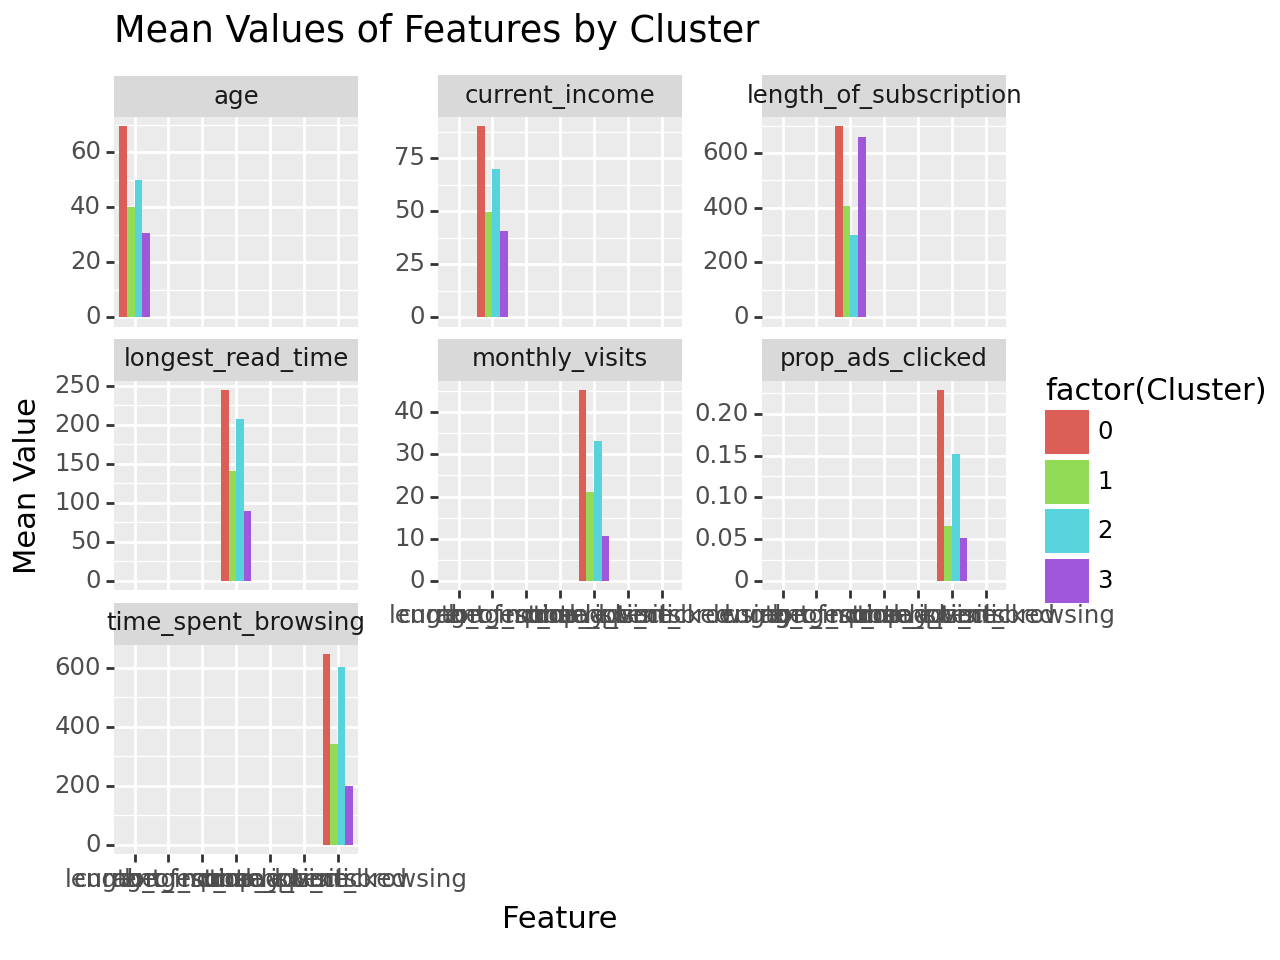

In [ ]:
# summary of clusters using groupby
behav["Cluster"] = labels

numeric_features = behav.drop(columns=["id"]).select_dtypes(include="number")
cluster_summary = numeric_features.groupby("Cluster").mean().reset_index()

print(cluster_summary)

# summary of clusters using ggplot
cluster_summary_melted = pd.melt(cluster_summary, id_vars=["Cluster"], var_name="Feature", value_name="Mean Value")

# Plot bar plot for each feature
bar_plot = (ggplot(cluster_summary_melted, aes(x="Feature", y="Mean Value", fill="factor(Cluster)")) +
            geom_bar(stat="identity", position="dodge") +
            facet_wrap("~Feature", scales="free_y") +
            ggtitle("Mean Values of Features by Cluster"))

print(bar_plot)

Article Clustering

In [ ]:
# read in data
article = pd.read_csv("https://raw.githubusercontent.com/cmparlettpelleriti/CPSC392ParlettPelleriti/master/Data/HW3_topics.csv")

article.head()

,Stocks,Productivity,Fashion,Celebrity,Cryptocurrency,Science,Technology,SelfHelp,Fitness,AI,id
0,3,12,9,9,1,1,5,1,0,1,198
1,1,0,1,1,0,8,4,10,4,0,92
2,4,1,11,1,6,11,0,9,0,0,75
3,2,6,8,1,15,1,1,9,8,0,147
4,1,2,4,4,6,6,2,1,3,4,136


In [ ]:
# select features
features = ["Stocks", "Productivity", "Fashion", "Celebrity", "Cryptocurrency", "Science", "Technology", "SelfHelp", "Fitness", "AI"]
X = article[features]

pipe2 = AgglomerativeClustering(affinity = "cosine",
                             linkage = "average",
                             distance_threshold=0,
                             n_clusters = None)

# fit the pipeline to the data
pipe2.fit(X)

AgglomerativeClustering(affinity='cosine', distance_threshold=0,
                        linkage='average', n_clusters=None)

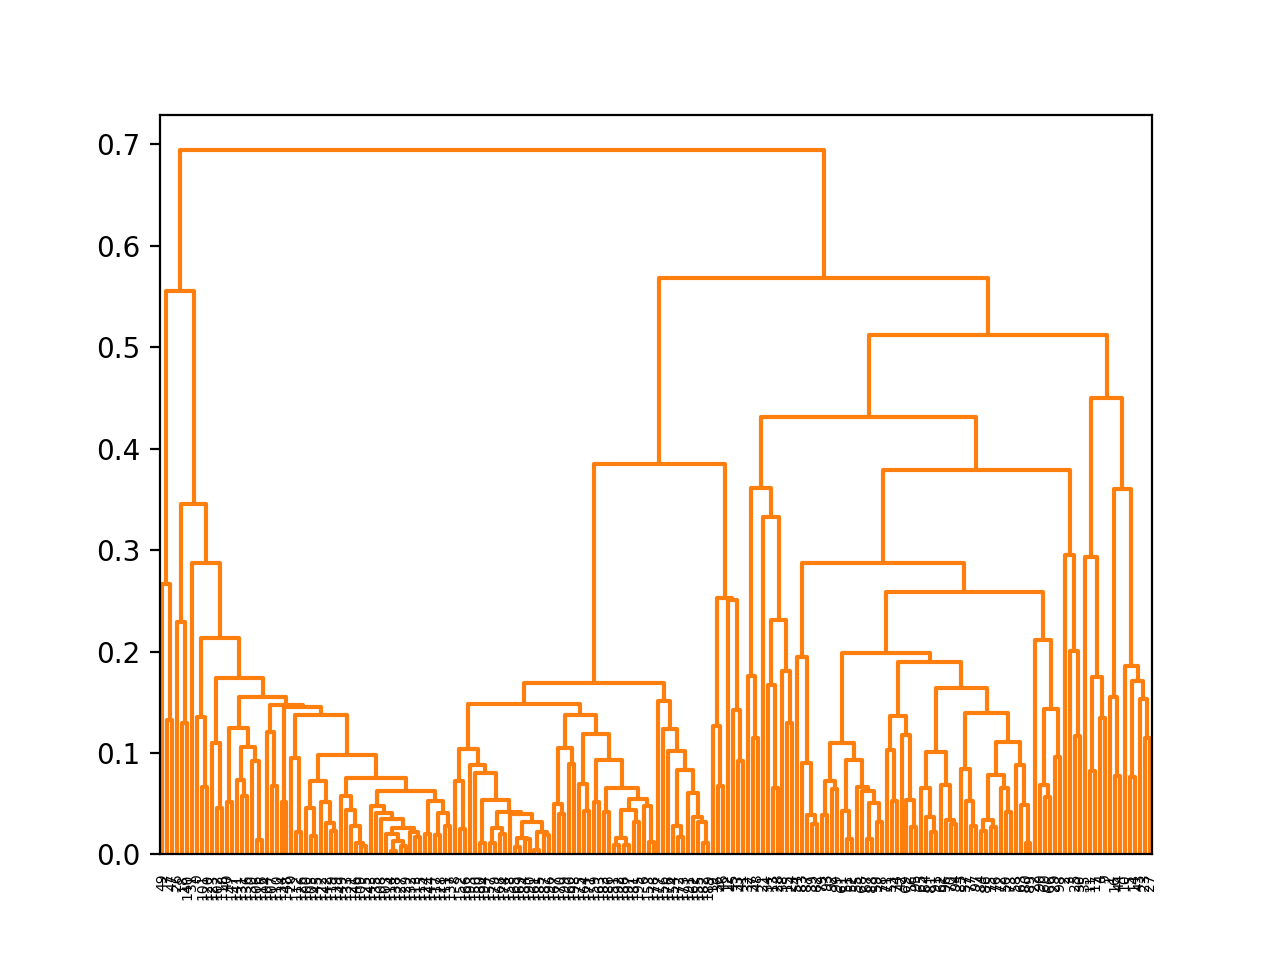

In [ ]:
# dendrogram
# choosing number of clusters

def plot_dendrogram(pipe2, **kwargs):
    # Check if the model has the necessary attributes
    if not hasattr(pipe2, "children_"):
        raise ValueError("The model must have the 'children_' attribute for this function to work.")

    # create the counts of samples under each node
    counts = np.zeros(pipe2.children_.shape[0])
    n_samples = len(pipe2.labels_)
    for i, merge in enumerate(pipe2.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [pipe2.children_, pipe2.distances_, counts]
    ).astype(float)

    # plot the corresponding dendrogram
    sch.dendrogram(linkage_matrix, **kwargs)

# Usage
plot_dendrogram(pipe2, color_threshold=5)

In [ ]:
# refit model with # of clusters you want
pipe2 = AgglomerativeClustering(affinity = "cosine",
                             linkage = "average",
                             distance_threshold= None,
                             n_clusters = 5)

# fit the pipeline to the data
pipe2.fit(X)

AgglomerativeClustering(affinity='cosine', linkage='average', n_clusters=5)

In [ ]:
# performance of model based on dendrogram
print(silhouette_score(X[features], labels))

0.2636056894628793


   Cluster     Stocks  Productivity    Fashion  Celebrity  Cryptocurrency  \
0        0   3.680000      3.420000   3.120000   2.960000        4.340000   
1        1  10.673469     13.428571   1.755102   0.000000        1.938776   
2        2   3.980392      4.803922   4.196078   3.921569        3.666667   
3        3   1.920000      2.340000  13.460000  17.920000        1.400000   

     Science  Technology   SelfHelp   Fitness         AI  
0  16.380000   30.160000   3.580000  3.800000  29.460000  
1   3.693878    2.061224  18.102041  7.469388   9.530612  
2   4.705882    3.196078   4.941176  4.098039   3.529412  
3   1.880000    2.360000   2.420000  1.540000   1.980000  


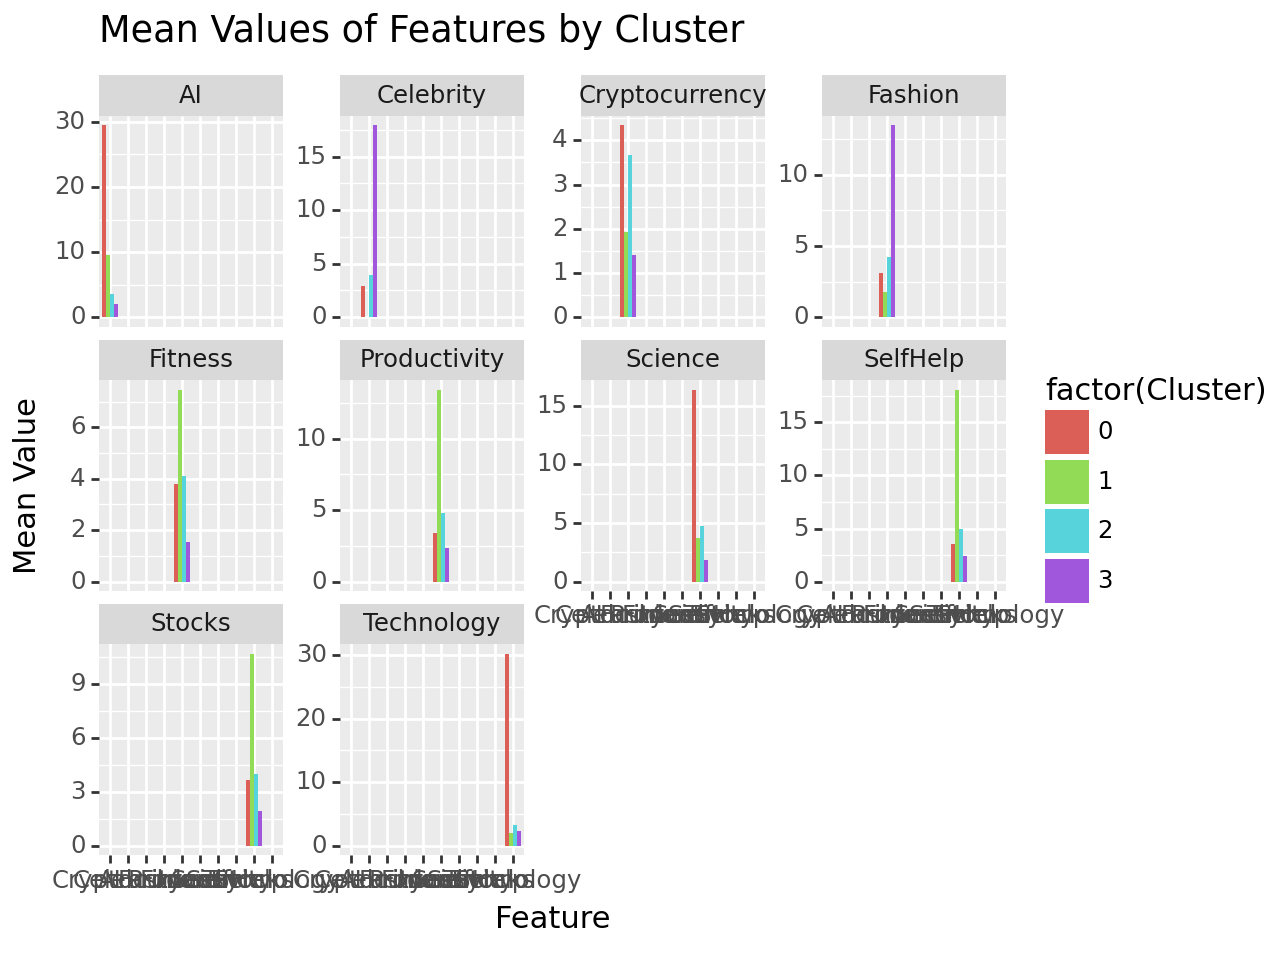

In [ ]:
# summary of clusters using groupby
article["Cluster"] = labels

numeric_features = article.drop(columns=["id"]).select_dtypes(include="number")
cluster_summary = numeric_features.groupby("Cluster").mean().reset_index()

print(cluster_summary)

# summary of clusters using ggplot
cluster_summary_melted = pd.melt(cluster_summary, id_vars=["Cluster"], var_name="Feature", value_name="Mean Value")

# bar plot for each feature
bar_plot = (ggplot(cluster_summary_melted, aes(x="Feature", y="Mean Value", fill="factor(Cluster)")) +
            geom_bar(stat="identity", position="dodge") +
            facet_wrap("~Feature", scales="free_y") +
            ggtitle("Mean Values of Features by Cluster"))

print(bar_plot)